In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def load_mat(filepath):
    """

    """
    try:
        from scipy.io import loadmat
        data = loadmat(filepath, squeeze_me=True, struct_as_record=False)
        data = {k: v for k, v in data.items() if not k.startswith("__")}
        return data, "scipy"
    except NotImplementedError:
        import h5py
        f = h5py.File(filepath, "r")
        return f, "h5py"

def list_keys(data, mode):
    if mode == "scipy":
        print("Keys:", list(data.keys()))
    else:
        print("Top-level keys:", list(data.keys()))

def plot_two_channel(time_s, voltage_mv, current, outpath=None, title=None):
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        sharex=True,
        figsize=(8, 4.8),
        gridspec_kw={"height_ratios": [2, 1]}
    )

    
    ax1.plot(time_s, voltage_mv)
    ax1.set_ylabel("Membrane V (mV)")
    if title:
        ax1.set_title(title)


    ax2.plot(time_s, current)
    ax2.set_ylabel("Injected I (a.u.)")
    ax2.set_xlabel("Time (s)")


    for ax in (ax1, ax2):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.tight_layout()

    if outpath:
        fig.savefig(outpath, dpi=300, bbox_inches="tight")

    plt.show()


filepath = "/Users/edah./Downloads/neuro 440/Lab_3_Demo_Data.mat"

data, mode = load_mat(filepath)
list_keys(data, mode)


Keys: ['data', 'datastart', 'dataend', 'titles', 'rangemin', 'rangemax', 'unittext', 'unittextmap', 'blocktimes', 'tickrate', 'samplerate', 'firstsampleoffset', 'comtext', 'com']


In [6]:
print(data["titles"])
print(data["unittext"])

['Channel 1' 'Channel 2']
V


In [11]:
print("titles:", data["titles"])
print("unittext:", data["unittext"])
print("rangemin:", data["rangemin"])
print("rangemax:", data["rangemax"])
print("samplerate:", data["samplerate"])
print("data shape:", np.shape(data["data"]))

titles: ['Channel 1' 'Channel 2']
unittext: V
rangemin: [[-0.2 -0.2 -0.2 -0.2 -0.2 -0.2 -0.2 -0.2 -0.2 -0.2 -0.2 -0.2 -0.2 -0.2
  -0.2 -0.2 -0.2 -0.2 -0.2 -0.2 -0.5 -0.5 -0.5 -0.5 -0.5]
 [-2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.
  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2. ]]
rangemax: [[0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2
  0.2 0.2 0.5 0.5 0.5 0.5 0.5]
 [2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.
  2.  2.  2.  2.  2.  2.  2. ]]
samplerate: [[100000. 100000. 100000. 100000. 100000. 100000. 100000. 100000. 100000.
  100000.  40000.  40000.  40000.  40000.  40000.  40000.  40000.  40000.
   40000.  40000.  40000.  40000.  40000.  40000.  40000.]
 [100000. 100000. 100000. 100000. 100000. 100000. 100000. 100000. 100000.
  100000.  40000.  40000.  40000.  40000.  40000.  40000.  40000.  40000.
   40000.  40000.  40000.  40000.  40000.  40000.  40000.]]
data shape: (64000000,)


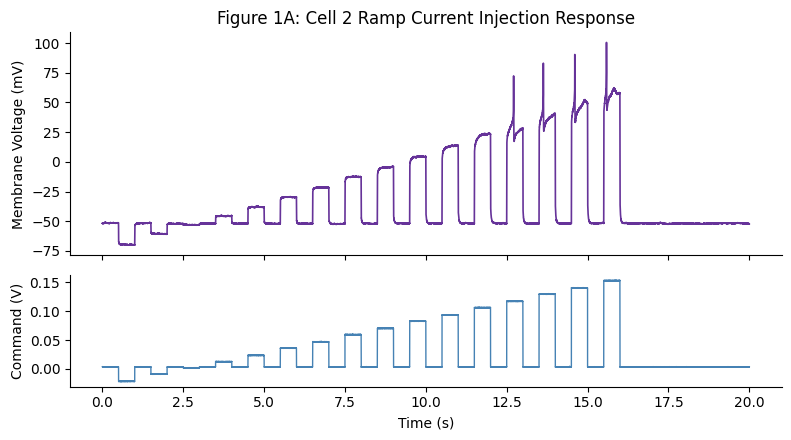

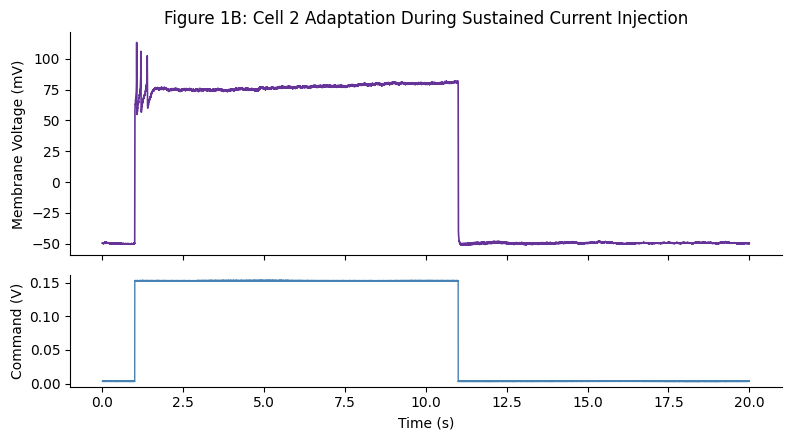

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def get_block(block_idx, ch_idx):
    """
    block_idx : which recording block
    ch_idx    : 0 = membrane voltage
                1 = command/current
    """
    s = int(datastart[ch_idx, block_idx])
    e = int(dataend[ch_idx, block_idx])
    sig = raw[s:e+1]
    Fs = float(samplerate[ch_idx, block_idx])
    return sig, Fs



def plot_recording(block_idx, title, save_name):

    voltage_V, Fs = get_block(block_idx, 0)
    command, _ = get_block(block_idx, 1)

    
    voltage_mV = voltage_V * 1000

 
    t = np.arange(len(voltage_mV)) / Fs

    
    ds = max(1, int(Fs / 2000))

    t = t[::ds]
    voltage_mV = voltage_mV[::ds]
    command = command[::ds]

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        sharex=True,
        figsize=(8,4.5),
        gridspec_kw={"height_ratios":[2,1]}
    )


    ax1.plot(t, voltage_mV, color="rebeccapurple", linewidth=1.2)
    ax1.set_ylabel("Membrane Voltage (mV)")
    ax1.set_title(title)

    # command signal
    ax2.plot(t, command, color="steelblue", linewidth=1)
    ax2.set_ylabel("Command (V)")
    ax2.set_xlabel("Time (s)")

    # cleaner style
    for ax in (ax1, ax2):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_name, dpi=300)
    plt.show()


plot_recording(
    block_idx=10,
    title="Figure 1A: Cell 2 Ramp Current Injection Response",
    save_name="/Users/edah./Downloads/neuro 440/Figure1A_Ramp.png"
)


plot_recording(
    block_idx=15,
    title="Figure 1B: Cell 2 Adaptation During Sustained Current Injection",
    save_name="/Users/edah./Downloads/neuro 440/Figure1B_Adaptation.png"
)

R (slope) ≈ 7.32 MΩ
Intercept ≈ -0.29 mV


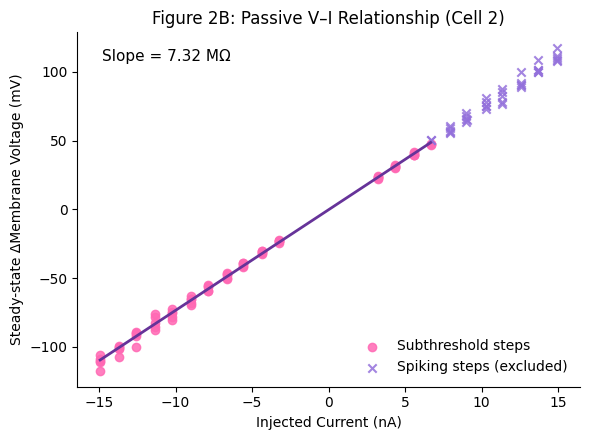

tau ≈ 83.43 ms


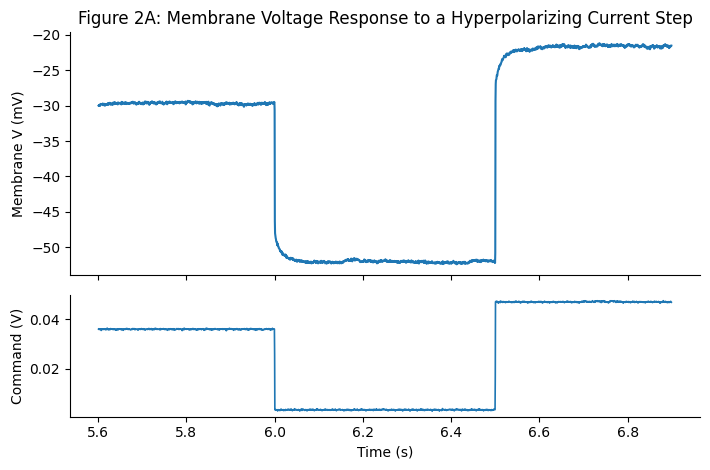


--- Membrane Property Estimates (Cell 2) ---
Membrane resistance (R): 7.32 MΩ
Time constant (tau):     83.43 ms
Membrane capacitance (C): 11.394 nF


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def get_block(block_idx, ch_idx):
    """
    block_idx : which recording block
    ch_idx    : 0 = membrane voltage (V)
                1 = command signal (V)  -> assumed proportional to injected current
    """
    s = int(datastart[ch_idx, block_idx])
    e = int(dataend[ch_idx, block_idx])
    sig = raw[s:e+1]
    Fs = float(samplerate[ch_idx, block_idx])
    return sig, Fs


def find_step_windows(command, Fs, min_step_dur_s=0.25):
    """
    Detect step plateaus in command channel by detecting transitions.
    Returns list of (start_idx, end_idx) plateau segments.
    """
    cmd = command.copy()

    k = max(1, int(0.002 * Fs))
    if k > 1:
        cmd = np.convolve(cmd, np.ones(k) / k, mode="same")

    d = np.diff(cmd)
    thr = max(np.max(np.abs(d)) * 0.2, 1e-6)
    transitions = np.where(np.abs(d) > thr)[0]

    bounds = [0] + (transitions + 1).tolist() + [len(cmd)]
    bounds = sorted(set(bounds))

    min_len = int(min_step_dur_s * Fs)
    plateaus = []
    for i in range(len(bounds) - 1):
        a, b = bounds[i], bounds[i + 1]
        if b - a >= min_len:
            plateaus.append((a, b))
    return plateaus


def steady_state_delta(voltage_mV, command_V, Fs, plateau,
                       baseline_window_s=0.2, steady_window_s=0.2):
    """
    ΔV and ΔI for a plateau relative to the immediate baseline before the plateau.
    """
    start, end = plateau
    bw = int(baseline_window_s * Fs)
    sw = int(steady_window_s * Fs)

    b0 = max(0, start - bw)
    baseline_V = np.mean(voltage_mV[b0:start]) if start > b0 else np.mean(voltage_mV[:bw])
    baseline_cmd = np.mean(command_V[b0:start]) if start > b0 else np.mean(command_V[:bw])

    s0 = max(start, end - sw)
    steady_V = np.mean(voltage_mV[s0:end])
    steady_cmd = np.mean(command_V[s0:end])

    dV = steady_V - baseline_V
    dCmd = steady_cmd - baseline_cmd
    return dV, dCmd


def has_spikes(voltage_mV, start, end, spike_thresh_mV=0):
    return np.max(voltage_mV[start:end]) > spike_thresh_mV


def fit_tau(voltage_mV, Fs, plateau, baseline_window_s=0.2, fit_window_s=0.3):
    start, end = plateau
    bw = int(baseline_window_s * Fs)
    fw = int(fit_window_s * Fs)

    b0 = max(0, start - bw)
    V0 = np.mean(voltage_mV[b0:start]) if start > b0 else np.mean(voltage_mV[:bw])
    V_inf = np.mean(voltage_mV[max(start, end - int(0.2 * Fs)):end])

    t1 = min(end, start + fw)
    V = voltage_mV[start:t1]
    t = np.arange(len(V)) / Fs

    y = V - V_inf
    sign = np.sign(V0 - V_inf)
    mask = (np.sign(y) == sign) & (np.abs(y) > 0.5)

    if np.sum(mask) < 10:
        return np.nan

    y_use = np.abs(y[mask])
    t_use = t[mask]

    slope, intercept = np.polyfit(t_use, np.log(y_use), 1)
    if slope >= 0:
        return np.nan

    tau = -1 / slope
    return tau


SAVE_DIR = "/Users/edah./Downloads/neuro 440"

ramp_blocks = [10, 11, 12, 13, 14]


COMMAND_V_TO_NA = 100.0

all_dV_mV = []
all_dI_nA = []
all_spiking = []

for blk in ramp_blocks:
    voltage_V, Fs = get_block(blk, 0)
    command_V, _ = get_block(blk, 1)

    voltage_mV = voltage_V * 1000
    plateaus = find_step_windows(command_V, Fs)

    for (a, b) in plateaus:
        dV, dCmd = steady_state_delta(voltage_mV, command_V, Fs, (a, b))

        if np.abs(dCmd) < 1e-4:
            continue

        spk = has_spikes(voltage_mV, a, b, spike_thresh_mV=0)

        all_dV_mV.append(dV)
        all_dI_nA.append(dCmd * COMMAND_V_TO_NA)
        all_spiking.append(spk)

all_dV_mV = np.array(all_dV_mV)
all_dI_nA = np.array(all_dI_nA)
all_spiking = np.array(all_spiking)

mask_passive = ~all_spiking
dV_pass = all_dV_mV[mask_passive]
dI_pass = all_dI_nA[mask_passive]

fit = np.polyfit(dI_pass, dV_pass, 1)
R_MOhm = fit[0]
b_int = fit[1]

print(f"R (slope) ≈ {R_MOhm:.2f} MΩ")
print(f"Intercept ≈ {b_int:.2f} mV")

# ---------- Figure 2B ----------
plt.figure(figsize=(6.0, 4.5))

plt.scatter(dI_pass, dV_pass, color="hotpink", label="Subthreshold steps", alpha=0.85)
plt.scatter(all_dI_nA[all_spiking], all_dV_mV[all_spiking],
            color="mediumpurple", marker="x", label="Spiking steps (excluded)", alpha=0.85)

x = np.linspace(np.min(dI_pass), np.max(dI_pass), 200)
y = R_MOhm * x + b_int
plt.plot(x, y, color="rebeccapurple", linewidth=2)

plt.xlabel("Injected Current (nA)")
plt.ylabel("Steady-state ΔMembrane Voltage (mV)")
plt.title("Figure 2B: Passive V–I Relationship (Cell 2)")

plt.text(
    0.05, 0.92,
    f"Slope = {R_MOhm:.2f} MΩ",
    transform=plt.gca().transAxes,
    fontsize=11
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/Figure2B_VI.png", dpi=300)
plt.show()


voltage_V, Fs = get_block(10, 0)
command_V, _ = get_block(10, 1)
voltage_mV = voltage_V * 1000
t = np.arange(len(voltage_mV)) / Fs

plateaus = find_step_windows(command_V, Fs)

tau_plateau = None
for (a, b) in plateaus:
    dV, dCmd = steady_state_delta(voltage_mV, command_V, Fs, (a, b))
    if (dCmd < -1e-3) and (not has_spikes(voltage_mV, a, b, spike_thresh_mV=0)):
        tau_plateau = (a, b)
        break

if tau_plateau is None:
    tau_s = np.nan
    print("Could not automatically find a clean hyperpolarizing step for tau.")
else:
    tau_s = fit_tau(voltage_mV, Fs, tau_plateau)
    print(f"tau ≈ {tau_s*1000:.2f} ms")

    a, b = tau_plateau

    pad = int(0.4 * Fs)
    w0 = max(0, a - pad)
    w1 = min(len(voltage_mV), b + pad)

    ds = max(1, int(Fs / 2000))
    tt = t[w0:w1:ds]
    vv = voltage_mV[w0:w1:ds]
    cc = command_V[w0:w1:ds]

    fig, (ax1, ax2) = plt.subplots(
        2, 1, sharex=True, figsize=(7.2, 4.8),
        gridspec_kw={"height_ratios":[2, 1]}
    )

    ax1.plot(tt, vv, linewidth=1.5)
    ax1.set_ylabel("Membrane V (mV)")
    ax1.set_title("Figure 2A: Membrane Voltage Response to a Hyperpolarizing Current Step")

    ax2.plot(tt, cc, linewidth=1.2)
    ax2.set_ylabel("Command (V)")
    ax2.set_xlabel("Time (s)")

    for ax in (ax1, ax2):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/Figure2A_ChargingCurve.png", dpi=300)
    plt.show()

if np.isfinite(tau_s):
    C_F = tau_s / (R_MOhm * 1e6)
    C_nF = C_F * 1e9
else:
    C_nF = np.nan

print("\n--- Membrane Property Estimates (Cell 2) ---")
print(f"Membrane resistance (R): {R_MOhm:.2f} MΩ")
print(f"Time constant (tau):     {tau_s*1000:.2f} ms")
print(f"Membrane capacitance (C): {C_nF:.3f} nF")

In [ ]:

resting = np.min(v_win)        
peak = np.max(v_win)               
amplitude = peak - resting

half_height = resting + amplitude/2

crossings = np.where(np.diff(v_win > half_height))[0]

if len(crossings) >= 2:
    spike_width = (t_win[crossings[1]] - t_win[crossings[0]])
else:
    spike_width = np.nan

print("Resting potential:", resting, "mV")
print("Spike peak:", peak, "mV")
print("Spike amplitude:", amplitude, "mV")
print("Spike width (half-height):", spike_width, "ms")

Resting potential: 95.13106514252722 mV
Spike peak: 152.35606525577606 mV
Spike amplitude: 57.22500011324884 mV
Spike width (half-height): 5.7000000000009265 ms


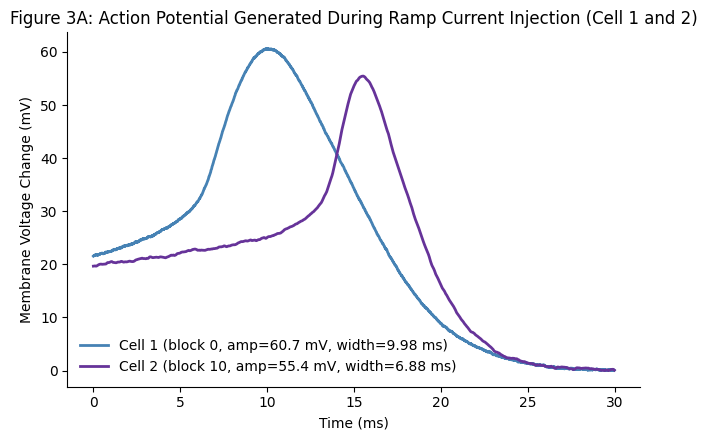

Cell 1 used block: 0
  Spike amplitude: 60.65625 mV
  Spike width: 9.979999999998768 ms

Cell 2 used block: 10
  Spike amplitude: 55.449997 mV
  Spike width: 6.875000000000853 ms


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

SAVE_PATH = "/Users/edah./Downloads/neuro 440/Figure3_Cell1_Cell2_overlay.png"

cell1_blocks = [0, 1, 2, 3, 4]   
cell2_block = 10                  

def extract_spike_relative(block, pre_ms=10, post_ms=20, search_start_s=8, threshold_mV=None):
    """
    Find a spike in the later part of the ramp, extract a window around it,
    and baseline-correct so local rest = 0 mV.
    """
    voltage_V, Fs = get_block(block, 0)
    voltage_mV = voltage_V * 1000
    t = np.arange(len(voltage_mV)) / Fs

    start_idx = int(search_start_s * Fs)
    v_search = voltage_mV[start_idx:]

    if threshold_mV is None:
        threshold_mV = np.min(v_search) + 0.6 * (np.max(v_search) - np.min(v_search))

    crossings = np.where((v_search[:-1] < threshold_mV) & (v_search[1:] >= threshold_mV))[0]
    if len(crossings) == 0:
        raise ValueError(f"No spike found in block {block} with threshold {threshold_mV:.1f} mV.")

    spike_idx = crossings[0] + start_idx


    peak_window = int(0.005 * Fs)
    local_end = min(len(voltage_mV), spike_idx + peak_window)
    peak_idx = spike_idx + np.argmax(voltage_mV[spike_idx:local_end])

    pre = int((pre_ms / 1000) * Fs)
    post = int((post_ms / 1000) * Fs)

    w0 = max(0, peak_idx - pre)
    w1 = min(len(voltage_mV), peak_idx + post)

    t_win = (t[w0:w1] - t[w0]) * 1000
    v_win = voltage_mV[w0:w1]

    resting = np.min(v_win)
    v_rel = v_win - resting

    amplitude = np.max(v_rel)
    half_height = amplitude / 2
    crossings_hw = np.where(np.diff(v_rel > half_height))[0]

    if len(crossings_hw) >= 2:
        width = t_win[crossings_hw[1]] - t_win[crossings_hw[0]]
    else:
        width = np.nan

    return t_win, v_rel, amplitude, width, block

cell1_result = None
for b in cell1_blocks:
    try:
        cell1_result = extract_spike_relative(b, threshold_mV=None)
        break
    except ValueError:
        continue

if cell1_result is None:
    raise ValueError("No usable Cell 1 spike found in blocks 0–4.")

t1, v1, amp1, width1, used_cell1_block = cell1_result

# Cell 2
t2, v2, amp2, width2, used_cell2_block = extract_spike_relative(cell2_block, threshold_mV=None)

# plot
plt.figure(figsize=(6.5, 4.5))

plt.plot(t1, v1, color="steelblue", linewidth=2,
         label=f"Cell 1 (block {used_cell1_block}, amp={amp1:.1f} mV, width={width1:.2f} ms)")
plt.plot(t2, v2, color="rebeccapurple", linewidth=2,
         label=f"Cell 2 (block {used_cell2_block}, amp={amp2:.1f} mV, width={width2:.2f} ms)")

plt.xlabel("Time (ms)")
plt.ylabel("Membrane Voltage Change (mV)")
plt.title("Figure 3A: Action Potential Generated During Ramp Current Injection (Cell 1 and 2)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=300)
plt.show()

print("Cell 1 used block:", used_cell1_block)
print("  Spike amplitude:", amp1, "mV")
print("  Spike width:", width1, "ms")

print("\nCell 2 used block:", used_cell2_block)
print("  Spike amplitude:", amp2, "mV")
print("  Spike width:", width2, "ms")

In [ ]:
import numpy as np
from scipy.io import loadmat

data = loadmat("/Users/edah./Downloads/neuro 440/Lab_3_Demo_Data.mat")

raw = data["data"].flatten()
datastart = data["datastart"]
dataend = data["dataend"]
samplerate = data["samplerate"]

def get_block(block_idx, channel_idx):
    """
    Returns voltage/current trace for a specific block and channel.
    """
    start = int(datastart[channel_idx, block_idx]) - 1
    end = int(dataend[channel_idx, block_idx])
    trace = raw[start:end]
    Fs = samplerate[channel_idx, block_idx]
    return trace, Fs

In [39]:
v, Fs = get_block(5,0)
print(len(v), Fs)

2000000 99999.99999999999


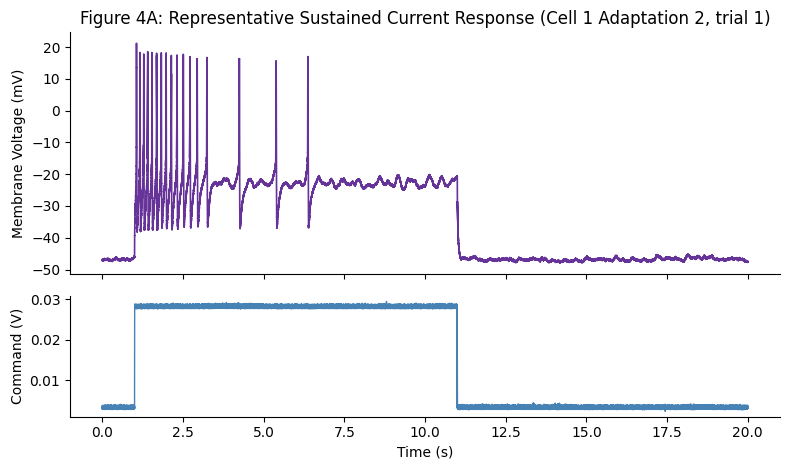

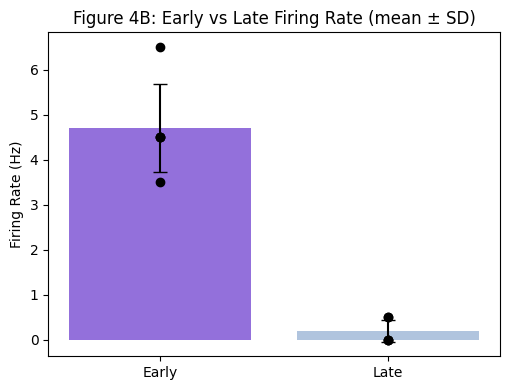

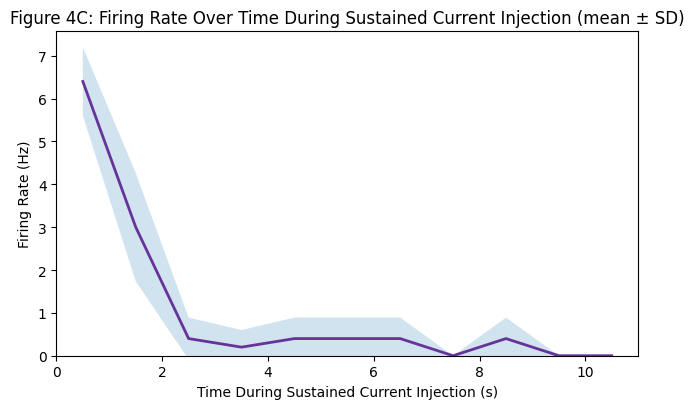

Adaptation dataset: Cell 1 Adaptation 2
Early rates (Hz): [6.5 4.5 3.5 4.5 4.5]
Late rates (Hz): [0.  0.  0.5 0.  0.5]
Mean early firing rate: 4.7
Mean late firing rate: 0.2
Error bars in Figure 4B and 4C = standard deviation (SD) across trials


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

SAVE_DIR = "/Users/edah./Downloads/neuro 440"


adapt_blocks = [5, 6, 7, 8, 9]
adapt_label = "Cell 1 Adaptation 2"


THRESHOLD_MV = -10
MIN_ISI_MS = 20
EARLY_WINDOW = 2.0
LATE_WINDOW = 2.0
BIN_WIDTH = 1.0  


def find_stimulus_window(command_V, Fs):
    baseline = np.median(command_V[:int(0.5 * Fs)])
    command_centered = command_V - baseline

    threshold = 0.3 * np.max(np.abs(command_centered))
    on = np.abs(command_centered) > threshold

    idx = np.where(on)[0]
    if len(idx) == 0:
        raise RuntimeError("No stimulus window found in command trace.")

    breaks = np.where(np.diff(idx) > 1)[0]
    starts = np.insert(idx[breaks + 1], 0, idx[0])
    ends = np.append(idx[breaks], idx[-1])

    lengths = ends - starts
    longest = np.argmax(lengths)

    return int(starts[longest]), int(ends[longest])

def detect_spikes(voltage_mV, Fs, threshold_mV=-10, min_isi_ms=20):
    crossings = np.where(
        (voltage_mV[:-1] < threshold_mV) &
        (voltage_mV[1:] >= threshold_mV)
    )[0] + 1

    if len(crossings) == 0:
        return np.array([], dtype=int)

    min_isi = int((min_isi_ms / 1000) * Fs)

    keep = [crossings[0]]
    for idx in crossings[1:]:
        if idx - keep[-1] >= min_isi:
            keep.append(idx)

    return np.array(keep, dtype=int)

def firing_rate_curve(spike_times_s, stim_duration_s, bin_width=1.0):
    bins = np.arange(0, stim_duration_s + bin_width, bin_width)
    counts, edges = np.histogram(spike_times_s, bins=bins)
    rate = counts / bin_width
    centers = edges[:-1] + bin_width / 2
    return centers, rate




rep_block = adapt_blocks[0]

voltage_V, Fs = get_block(rep_block, 0)
command_V, _ = get_block(rep_block, 1)

voltage_mV = voltage_V * 1000
t = np.arange(len(voltage_mV)) / Fs

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(8, 4.8),
    gridspec_kw={"height_ratios": [2, 1]}
)

ax1.plot(t, voltage_mV, color="rebeccapurple", linewidth=1.2)
ax1.set_ylabel("Membrane Voltage (mV)")
ax1.set_title(f"Figure 4A: Representative Sustained Current Response ({adapt_label}, trial 1)")

ax2.plot(t, command_V, color="steelblue", linewidth=1)
ax2.set_ylabel("Command (V)")
ax2.set_xlabel("Time (s)")

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/Figure4A_AdaptationTrace.png", dpi=300)
plt.show()



early_rates = []
late_rates = []
trial_rate_curves = []
stim_durations = []

for block in adapt_blocks:
    voltage_V, Fs = get_block(block, 0)
    command_V, _ = get_block(block, 1)

    voltage_mV = voltage_V * 1000

    stim_start, stim_end = find_stimulus_window(command_V, Fs)
    stim_duration = (stim_end - stim_start) / Fs
    stim_durations.append(stim_duration)

    voltage_stim = voltage_mV[stim_start:stim_end]

    spike_idx = detect_spikes(
        voltage_stim,
        Fs,
        threshold_mV=THRESHOLD_MV,
        min_isi_ms=MIN_ISI_MS
    )

    spike_times = spike_idx / Fs


    early_count = np.sum((spike_times >= 0) & (spike_times < EARLY_WINDOW))
    early_rate = early_count / EARLY_WINDOW

    late_start = max(0, stim_duration - LATE_WINDOW)
    late_count = np.sum((spike_times >= late_start) & (spike_times < stim_duration))
    late_rate = late_count / LATE_WINDOW

    early_rates.append(early_rate)
    late_rates.append(late_rate)

    
    centers, rate = firing_rate_curve(spike_times, stim_duration, bin_width=BIN_WIDTH)
    trial_rate_curves.append(rate)

early_rates = np.array(early_rates)
late_rates = np.array(late_rates)


mean_early = np.mean(early_rates)
mean_late = np.mean(late_rates)

sd_early = np.std(early_rates)
sd_late = np.std(late_rates)

plt.figure(figsize=(5.2, 4))

x = np.array([0, 1])
means = [mean_early, mean_late]
sds = [sd_early, sd_late]

plt.bar(
    x, means,
    yerr=sds,
    capsize=5,
    color=["mediumpurple", "lightsteelblue"]
)

plt.scatter(np.full_like(early_rates, 0), early_rates, color="black", zorder=3)
plt.scatter(np.full_like(late_rates, 1), late_rates, color="black", zorder=3)

plt.xticks([0, 1], ["Early", "Late"])
plt.ylabel("Firing Rate (Hz)")
plt.title("Figure 4B: Early vs Late Firing Rate (mean ± SD)")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/Figure4B_EarlyLateRate.png", dpi=300)
plt.show()


median_duration = float(np.median(stim_durations))
common_time = np.arange(0, median_duration, BIN_WIDTH) + BIN_WIDTH / 2

rate_matrix = np.full((len(trial_rate_curves), len(common_time)), np.nan)

for i, rate in enumerate(trial_rate_curves):
    n = min(len(rate), len(common_time))
    rate_matrix[i, :n] = rate[:n]

mean_rate = np.nanmean(rate_matrix, axis=0)
sd_rate = np.nanstd(rate_matrix, axis=0)

plt.figure(figsize=(6.5, 4.2))
plt.plot(common_time, mean_rate, color="rebeccapurple", linewidth=2)
plt.fill_between(
    common_time,
    mean_rate - sd_rate,
    mean_rate + sd_rate,
    alpha=0.2
)

plt.xlabel("Time During Sustained Current Injection (s)")
plt.ylabel("Firing Rate (Hz)")
plt.title("Figure 4C: Firing Rate Over Time During Sustained Current Injection (mean ± SD)")
plt.ylim(bottom=0)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/Figure4C_RateOverTime.png", dpi=300)
plt.show()

print("Adaptation dataset:", adapt_label)
print("Early rates (Hz):", early_rates)
print("Late rates (Hz):", late_rates)
print("Mean early firing rate:", mean_early)
print("Mean late firing rate:", mean_late)
print("Error bars in Figure 4B and 4C = standard deviation (SD) across trials")

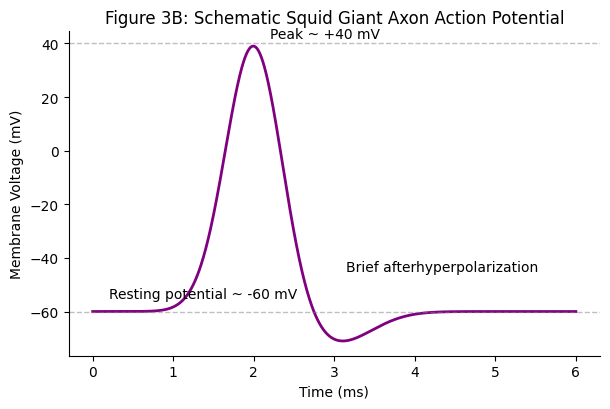

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

SAVE_PATH = "/Users/edah./Downloads/neuro 440/Figure3B_squid_axon_schematic.png"


t = np.linspace(0, 6, 1000)


baseline = -60 * np.ones_like(t)


upstroke_peak = 100 * np.exp(-0.5 * ((t - 2.0) / 0.35) ** 2)  
afterhyper = -12 * np.exp(-0.5 * ((t - 3.0) / 0.45) ** 2)     

v = baseline + upstroke_peak + afterhyper

plt.figure(figsize=(6.2, 4.2))
plt.plot(t, v, color="purple", linewidth=2)

plt.xlabel("Time (ms)")
plt.ylabel("Membrane Voltage (mV)")
plt.title("Figure 3B: Schematic Squid Giant Axon Action Potential")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.axhline(-60, linestyle="--", color="grey", alpha=0.5, linewidth=1)
plt.axhline(40, linestyle="--", color="grey", alpha=0.5, linewidth=1)


plt.text(0.2, -55, "Resting potential ~ -60 mV", fontsize=10)
plt.text(2.2, 42, "Peak ~ +40 mV", fontsize=10)
plt.text(3.15, -45, "Brief afterhyperpolarization", fontsize=10)

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=300)
plt.show()